# DNA EDA (Promoter vs Non-Promoter)

This notebook performs exploratory data analysis (EDA) on the processed DNA
classification dataset.

**Task:** Promoter vs Non-Promoter (binary)  
**Organism:** Human (GRCh38)  
**Sequence length:** Fixed (from config)

### What this notebook does
- Basic sanity checks (missing values, duplicates, length consistency)
- Label distribution analysis
- Sequence alphabet validation (ACGTN)
- GC content analysis
- CpG density analysis
- Plots saved under `reports/figures/`
- EDA summary saved under `reports/dna_eda_summary.json`

In [1]:
from pathlib import Path
import json
import platform
import sys

import numpy as np
import pandas as pd
import yaml

import matplotlib.pyplot as plt
import seaborn as sns

## Paths + config + load dataset

This notebook assumes it is located inside `notebooks/`, so the project root is
the parent directory of the current working directory.

In [2]:
ROOT = Path.cwd().parents[0]
PROCESSED = ROOT / "data" / "processed"
REPORTS = ROOT / "reports"
FIGURES = REPORTS / "figures"
CONFIGS = ROOT / "configs"

for p in [REPORTS, FIGURES]:
    p.mkdir(parents=True, exist_ok=True)

cfg_path = CONFIGS / "config.yaml"
assert cfg_path.exists(), f"Missing config file: {cfg_path}"

with open(cfg_path, "r") as f:
    cfg = yaml.safe_load(f)

L = int(cfg["dna"]["seq_length_bp"])
N_POS = int(cfg["dna"]["n_pos"])
N_NEG = int(cfg["dna"]["n_neg"])

in_csv = PROCESSED / f"dna_promoter_vs_nonpromoter_len{L}_pos{N_POS}_neg{N_NEG}.csv"
assert in_csv.exists(), f"Missing processed dataset: {in_csv}"

df = pd.read_csv(in_csv)
df.shape, df.head(3)

((4000, 6),
   region_id chrom      start        end  \
 0    prom_0     4   88592334   88592533   
 1    prom_1     5  120078977  120079176   
 2    prom_2     8    9371095    9371294   
 
                                             sequence  label  
 0  TGCCCGCGGACCTTGCCGCCCCGCCTCCAGCCCGTGCCACGGCGGC...      1  
 1  AGAAAGAAGGAGAAAAAACGGCTCAAAGAAGAGTTGATGGCTGGGA...      1  
 2  TATGGAAAGCTTCACAAATTTGCACGGCATCTTTGTGCAGGGCCGT...      1  )

## Basic validation checks

We verify:
- required columns exist
- no missing values
- no duplicate region IDs
- sequence length consistency

In [3]:
required = ["region_id", "chrom", "start", "end", "sequence", "label"]
missing_cols = [c for c in required if c not in df.columns]
assert not missing_cols, f"Missing columns: {missing_cols}"

# missing values
df[required].isna().sum()

region_id    0
chrom        0
start        0
end          0
sequence     0
label        0
dtype: int64

In [4]:
# duplicates
dup_regions = int(df["region_id"].duplicated().sum())
dup_seq_label = int(df.duplicated(subset=["sequence", "label"]).sum())

dup_regions, dup_seq_label

(0, 155)

In [5]:
# sequence length consistency
seq_len = df["sequence"].str.len()
n_mismatch = int((seq_len != L).sum())

n_mismatch, seq_len.describe()

(0,
 count    4000.0
 mean      200.0
 std         0.0
 min       200.0
 25%       200.0
 50%       200.0
 75%       200.0
 max       200.0
 Name: sequence, dtype: float64)

## Label distribution

Check class balance between promoter (1) and non-promoter (0).

In [6]:
label_counts = df["label"].value_counts().sort_index()
label_counts

label
0    2000
1    2000
Name: count, dtype: int64

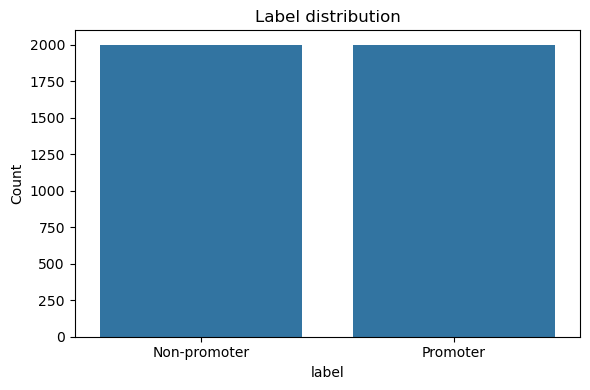

In [7]:
plt.figure(figsize=(6, 4))
sns.barplot(x=label_counts.index, y=label_counts.values)
plt.xticks([0, 1], ["Non-promoter", "Promoter"])
plt.ylabel("Count")
plt.title("Label distribution")
plt.tight_layout()
plt.savefig(FIGURES / "dna_label_distribution.png", dpi=200)
plt.show()

## Sequence alphabet sanity

Ensure sequences contain only valid DNA characters: **A, C, G, T, N**.

In [8]:
valid_chars = set("ACGTN")

def has_invalid_chars(seq: str) -> bool:
    return any(ch not in valid_chars for ch in seq)

df["invalid_char_flag"] = df["sequence"].apply(has_invalid_chars)

df["invalid_char_flag"].value_counts()

invalid_char_flag
False    4000
Name: count, dtype: int64

## GC content analysis

Compute GC percentage per sequence and compare distributions by label.

In [9]:
def gc_content(seq: str) -> float:
    gc = sum(1 for ch in seq if ch in {"G", "C"})
    return gc / len(seq)

df["gc_content"] = df["sequence"].apply(gc_content)

df["gc_content"].describe()

count    4000.000000
mean        0.454612
std         0.151931
min         0.000000
25%         0.375000
50%         0.450000
75%         0.540000
max         0.875000
Name: gc_content, dtype: float64

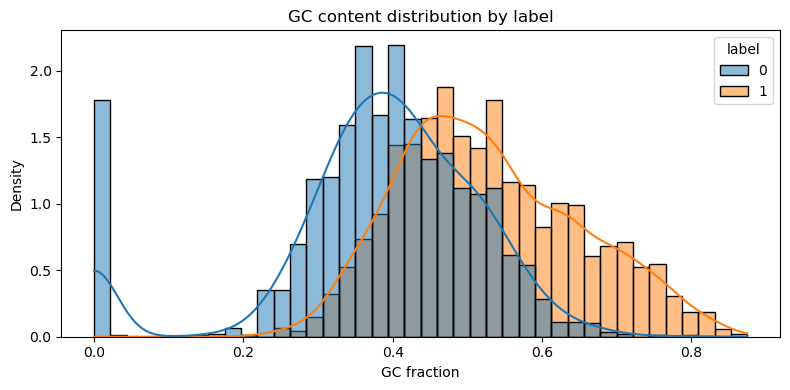

In [10]:
plt.figure(figsize=(8, 4))
sns.histplot(data=df, x="gc_content", hue="label", bins=40, kde=True, stat="density")
plt.xlabel("GC fraction")
plt.title("GC content distribution by label")
plt.tight_layout()
plt.savefig(FIGURES / "dna_gc_content_by_label.png", dpi=200)
plt.show()

## CpG density (simple proxy)

Counts occurrences of the dinucleotide "CG" per sequence and normalizes by length.
This is a simple CpG proxy commonly used in promoter analysis.

In [11]:
def cpg_density(seq: str) -> float:
    return seq.count("CG") / len(seq)

df["cpg_density"] = df["sequence"].apply(cpg_density)

df["cpg_density"].describe()

count    4000.000000
mean        0.023516
std         0.033844
min         0.000000
25%         0.005000
50%         0.010000
75%         0.025000
max         0.230000
Name: cpg_density, dtype: float64

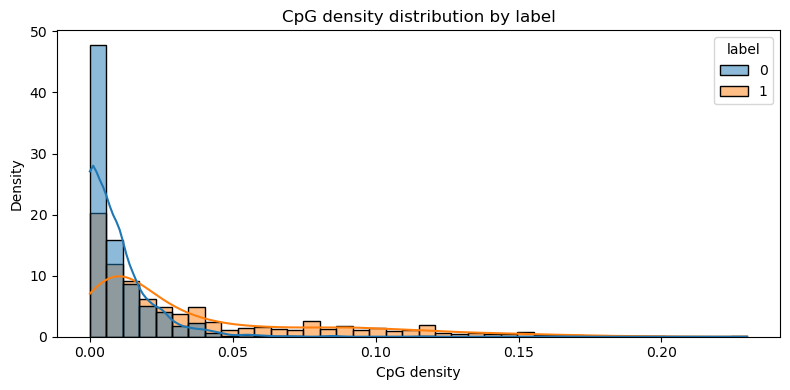

In [12]:
plt.figure(figsize=(8, 4))
sns.histplot(data=df, x="cpg_density", hue="label", bins=40, kde=True, stat="density")
plt.xlabel("CpG density")
plt.title("CpG density distribution by label")
plt.tight_layout()
plt.savefig(FIGURES / "dna_cpg_density_by_label.png", dpi=200)
plt.show()

## Save EDA summary

Write a compact JSON summary for reproducibility and reporting.

In [13]:
eda_summary = {
    "dataset_path": str(in_csv),
    "n_rows": int(df.shape[0]),
    "n_pos": int((df["label"] == 1).sum()),
    "n_neg": int((df["label"] == 0).sum()),
    "seq_length": int(L),
    "invalid_char_sequences": int(df["invalid_char_flag"].sum()),
    "gc_content": {
        "mean": float(df["gc_content"].mean()),
        "std": float(df["gc_content"].std()),
    },
    "cpg_density": {
        "mean": float(df["cpg_density"].mean()),
        "std": float(df["cpg_density"].std()),
    },
    "duplicates": {
        "dup_region_id": dup_regions,
        "dup_sequence_label": dup_seq_label,
    },
    "env": {
        "python_version": sys.version.split()[0],
        "platform": platform.platform(),
        "pandas": pd.__version__,
        "numpy": np.__version__,
    },
    "figures": {
        "label_distribution": str(FIGURES / "dna_label_distribution.png"),
        "gc_content_by_label": str(FIGURES / "dna_gc_content_by_label.png"),
        "cpg_density_by_label": str(FIGURES / "dna_cpg_density_by_label.png"),
    },
}

eda_path = REPORTS / "dna_eda_summary.json"
with open(eda_path, "w") as f:
    json.dump(eda_summary, f, indent=2)

eda_path

PosixPath('/Users/saturnine/Projects/bio-seq-lm-capstone/reports/dna_eda_summary.json')